# Exjobb Latency Analysis

In [1]:
%pip install numpy matplotlib pandas scipy

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import LogLocator, FuncFormatter, ScalarFormatter

Note: you may need to restart the kernel to use updated packages.


In [2]:
def get_experiment_info(expid):
    info = {}
    with open(f'./traces/{expid}/info.txt', 'r') as f:
        for i, line in enumerate(f):
            if i == 7:
                info['Dataplane'] = line.split(':')[1].strip()
            elif i == 8:
                info['Protocol'] = line.split(':')[1].strip()
            elif i == 9:
                info['Policy Direction'] = line.split(':')[1].strip()
            elif i == 10:
                info['Istio Installed'] = line.split(':')[1].strip().replace("withacceleration", "W/accel.")
            elif i == 11:
                info['Istio Policy'] = line.split(':')[1].strip()

    return info

def get_trace_dataset(expid, runid):
    df = pd.read_csv(f'./traces/{expid}/{runid}/{runid}-trace.csv')

    # HTTP requests always have a warm up time, remove the first three requests
    protocol = get_experiment_info(expid)["Protocol"]
    if protocol == "http":
        df = df[3:]

    return df





def get_experiment_id(exp):
    return exp if isinstance(exp, str) else exp['id']


def get_run_ids(exp, default=('1', '2', '3')):
    if isinstance(exp, dict):
        return exp.get('runs', default)
    return default


def get_delay_key_for_experiment(expid):
    return 'delay' if get_experiment_info(expid)['Protocol'] == 'udp' else 'Delay (s)'


def get_combined_trace_dataset(expid, runids=('1', '2', '3')):
    frames = []
    for runid in runids:
        frames.append(get_trace_dataset(expid, runid).copy())
    return pd.concat(frames, ignore_index=True)


def get_clean_latency_series(df, delay_key='delay', protocol='udp'):
    latencies = df[delay_key]

    # HTTP requests always have a warm up time, remove the first three requests
    #if protocol == 'http':
    #    latencies = latencies.iloc[3:]

    return latencies


def get_combined_latency_series(exp, delay_key=None):
    expid = get_experiment_id(exp)
    info = get_experiment_info(expid)
    if delay_key is None:
        delay_key = get_delay_key_for_experiment(expid)

    df = get_combined_trace_dataset(expid, get_run_ids(exp))
    series = get_clean_latency_series(df, delay_key=delay_key, protocol=info['Protocol'])
    # Convert seconds to milliseconds for consistent downstream use
    return series * 1000


def bootstrap_mean_ci(latencies, n_resamples=2000, confidence=0.95, seed=42):
    values = latencies.to_numpy()
    if len(values) == 0:
        return (np.nan, np.nan)

    rng = np.random.default_rng(seed)
    bootstrap_means = rng.choice(values, size=(n_resamples, len(values)), replace=True).mean(axis=1)
    alpha = (1 - confidence) / 2
    return tuple(np.quantile(bootstrap_means, [alpha, 1 - alpha]))


def get_latency_statistics(latencies):
    q1 = latencies.quantile(0.25)
    q3 = latencies.quantile(0.75)
    iqr = q3 - q1
    ci_low, ci_high = bootstrap_mean_ci(latencies)

    return {
        'count': len(latencies),
        'mean': latencies.mean(),
        'median': latencies.median(),
        'std': latencies.std(ddof=1),
        'iqr': iqr,
        'p95': latencies.quantile(0.95),
        'p99': latencies.quantile(0.99),
        'mean_ci_low': ci_low,
        'mean_ci_high': ci_high,
    }


def percentage_change(base_value, new_value):
    return ((new_value - base_value) / base_value) * 100


def format_change(base_value, new_value):
    change = percentage_change(base_value, new_value)
    if change < 0:
        return f"{abs(change):.1f}% faster"
    return f"{change:.1f}% slower"


def get_shared_latency_xlim(experiment_ids, delay_key=None):
    samples = []
    for expid in experiment_ids:
        latencies = get_combined_latency_series(expid, delay_key=delay_key).to_numpy()
        samples.append(latencies[latencies > 0])

    positive_samples = [sample for sample in samples if len(sample) > 0]
    if not positive_samples:
        return None

    combined = np.concatenate(positive_samples)
    lower = combined.min()
    upper = combined.max()

    if lower <= 0:
        lower = np.min(combined[combined > 0])
    if upper <= lower:
        upper = lower * 2

    lower_bound = max(lower * 0.9, np.finfo(float).tiny)
    upper_bound = upper * 1.1
    return (lower_bound, upper_bound)


def summarize_latency_experiments(experiment_ids, delay_key=None):
    rows = []
    for expid in experiment_ids:
        latencies = get_combined_latency_series(expid, delay_key=delay_key)
        stats = get_latency_statistics(latencies)
        info = get_experiment_info(expid)
        rows.append({
            'Experiment': expid,
            'Dataplane': info['Dataplane'],
            'Protocol': info['Protocol'],
            'Policy Direction': info['Policy Direction'],
            'Istio Installed': info['Istio Installed'],
            'Istio Policy': info['Istio Policy'],
            **stats,
        })

    return pd.DataFrame(rows)


def print_latency_summary(experiment_ids, delay_key=None):
    summary = summarize_latency_experiments(experiment_ids, delay_key=delay_key)
    print(summary.to_string(index=False))
    return summary


def print_relative_latency_change(base_exp, compare_exp, label, delay_key=None):
    base_id = get_experiment_id(base_exp)
    compare_id = get_experiment_id(compare_exp)
    base_latencies = get_combined_latency_series(base_exp, delay_key=delay_key)
    compare_latencies = get_combined_latency_series(compare_exp, delay_key=delay_key)
    base_mean = base_latencies.mean()
    compare_mean = compare_latencies.mean()
    change = percentage_change(base_mean, compare_mean)
    if change < 0:
        print(
            f"{label}: {compare_id} is {abs(change):.1f}% faster than {base_id} "
            f"(mean {compare_mean:.3f}ms vs {base_mean:.3f}ms)"
        )
    else:
        print(
            f"{label}: {compare_id} is {change:.1f}% slower than {base_id} "
            f"(mean {compare_mean:.3f}ms vs {base_mean:.3f}ms)"
        )

class FixedDecimalFormatter(ScalarFormatter):
    def _set_format(self):
        # 2. Force the desired format (e.g., 2 decimal places)
        self.format = "%1.3f" 


def get_trace_dataset_and_plot(experimentstocompare, axs, index, delay_key='Delay (s)', xlim=None):
    try:
        ax = axs[index] if index is not None else axs
    except Exception:
        ax = axs

    for exp in experimentstocompare:
        expid = get_experiment_id(exp)
        latencies = get_combined_latency_series(exp, delay_key=delay_key)
        stats = get_latency_statistics(latencies)

        print(
            f"{expid}: mean={stats['mean']:.3f}ms, median={stats['median']:.3f}ms, "
            f"std={stats['std']:.3f}ms, p95={stats['p95']:.3f}ms, p99={stats['p99']:.3f}ms"
        )

        sorted_lat_asc = np.sort(latencies.to_numpy())
        N = len(sorted_lat_asc)
        if N == 0:
            continue

        cdf = np.arange(1, N + 1) / N
        policy_label = get_experiment_info(expid)['Policy Direction']

        ax.plot(sorted_lat_asc, cdf, linewidth=2, label=policy_label)

    ax.set_xlabel('Latency (ms)')
    ax.set_ylabel('CDF')
    ax.set_title(f"{get_experiment_info(get_experiment_id(experimentstocompare[0]))['Dataplane']}")
    ax.grid(True)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(1e-3, 1.25)

    def _ms_formatter(x, pos):
        try:
            if x >= 1:
                return f"{x:.0f}"
            elif x >= 0.1:
                return f"{x:.1f}"
            else:
                return f"{x:.2f}"
        except Exception:
            return str(x)

    ax.xaxis.set_major_locator(LogLocator(base=10.0, subs=[1, 2, 5]))
    ax.xaxis.set_major_formatter(FuncFormatter(_ms_formatter))
    if xlim is not None:
        ax.set_xlim(xlim)
    ax.tick_params(which='major', length=6)
    ax.tick_params(which='minor', length=3)
    ax.legend(loc='lower right')


def get_trace_dataset_and_plot_istio(experimentstocompare, axs, index, delay_key='Delay (s)', xlim=None):
    try:
        ax = axs[index] if index is not None else axs
    except Exception:
        ax = axs

    for exp in experimentstocompare:
        expid = get_experiment_id(exp)
        latencies = get_combined_latency_series(exp, delay_key=delay_key)
        stats = get_latency_statistics(latencies)

        print(
            f"{expid}: mean={stats['mean']:.3f}ms, median={stats['median']:.3f}ms, "
            f"std={stats['std']:.3f}ms, p95={stats['p95']:.3f}ms, p99={stats['p99']:.3f}ms"
        )

        sorted_lat_asc = np.sort(latencies.to_numpy())
        N = len(sorted_lat_asc)
        if N == 0:
            continue

        cdf = np.arange(1, N + 1) / N
        label = f"Istio: {get_experiment_info(expid)['Istio Installed'].capitalize()} - Policy: {get_experiment_info(expid)['Istio Policy']}"

        ax.plot(sorted_lat_asc, cdf, linewidth=2, label=label)

    ax.set_xlabel('Latency (ms)')
    ax.set_ylabel('CDF')
    ax.set_title(f"Istio - {get_experiment_info(get_experiment_id(experimentstocompare[0]))['Dataplane']}")
    ax.grid(True)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(1e-3, 1.25)

    def _ms_formatter(x, pos):
        try:
            if x >= 1:
                return f"{x:.0f}"
            elif x >= 0.1:
                return f"{x:.1f}"
            else:
                return f"{x:.2f}"
        except Exception:
            return str(x)

    ax.xaxis.set_major_locator(LogLocator(base=10.0, subs=[1, 2, 5]))
    ax.xaxis.set_major_formatter(FuncFormatter(_ms_formatter))
    if xlim is not None:
        ax.set_xlim(xlim)
    ax.tick_params(which='major', length=6)
    ax.tick_params(which='minor', length=3)
    ax.legend(loc='lower right')


In [3]:
EBPF_UDP_EXPIDS = ["40816","40817","40818","40819"] # UDP random src-port
EBPF_HTTP_EXPIDS = ["40800","40801","40802","40803"]
EBPF_TCP_EXPIDS = ["40822","40823","40824","40825"]
EBPF_ISTIO_EXPIDS = ["40771","40773"]
EBPF_ISTIO_MERBRIDGE_EXPIDS = ["40774","40775"]

IPTABLES_UDP_EXPIDS = ["40812", "40813", "40814", "40815"] # UDP random src-port
IPTABLES_HTTP_EXPIDS = ["40780","40781","40782","40783"]
IPTABLES_TCP_EXPIDS = ["40826","40827","40828","40829"]
IPTABLES_ISTIO_EXPIDS = ["40785","40784"]
IPTABLES_ISTIO_MERBRIDGE_EXPIDS = ["40786","40787"]

In [4]:
combined_run_experiments = []
combined_run_experiments.extend(EBPF_UDP_EXPIDS)
combined_run_experiments.extend(EBPF_HTTP_EXPIDS)
combined_run_experiments.extend(EBPF_TCP_EXPIDS)
combined_run_experiments.extend(EBPF_ISTIO_EXPIDS)
combined_run_experiments.extend(EBPF_ISTIO_MERBRIDGE_EXPIDS)

combined_run_experiments.extend(IPTABLES_UDP_EXPIDS)
combined_run_experiments.extend(IPTABLES_HTTP_EXPIDS)
combined_run_experiments.extend(IPTABLES_TCP_EXPIDS)
combined_run_experiments.extend(IPTABLES_ISTIO_EXPIDS)
combined_run_experiments.extend(IPTABLES_ISTIO_MERBRIDGE_EXPIDS)


latency_summary = summarize_latency_experiments(combined_run_experiments)
latency_summary = latency_summary.sort_values(['Protocol', 'Dataplane', 'Experiment']).reset_index(drop=True)
print(latency_summary.to_string(index=False))


Experiment Dataplane Protocol Policy Direction Istio Installed Istio Policy  count     mean   median      std      iqr      p95      p99  mean_ci_low  mean_ci_high
     40771      ebpf     http             none            with         true   2991 0.987230 0.996292 0.205660 0.201583 1.173347 1.244235     0.980288      0.995093
     40773      ebpf     http             none            with        false   2991 0.969787 0.984907 0.156061 0.197411 1.166671 1.235253     0.964372      0.975886
     40774      ebpf     http             none        W/accel.         true   2991 0.999086 1.003861 0.209700 0.204087 1.190841 1.269627     0.992193      1.006825
     40775      ebpf     http             none        W/accel.        false   2991 0.981374 0.991642 0.185613 0.201940 1.176327 1.243162     0.974609      0.988521
     40800      ebpf     http             none              no        false   2991 0.408914 0.419795 0.133373 0.204921 0.573546 0.618553     0.404007      0.413830
     40801      

In [5]:
def get_shared_latency_xlim(experiment_ids, delay_key=None):
    samples = []
    for expid in experiment_ids:
        latencies = get_combined_latency_series(expid, delay_key=delay_key).to_numpy()
        samples.append(latencies[latencies > 0])

    positive_samples = [sample for sample in samples if len(sample) > 0]
    if not positive_samples:
        return None

    combined = np.concatenate(positive_samples)
    lower = combined.min()
    upper = combined.max()

    if lower <= 0:
        lower = np.min(combined[combined > 0])
    if upper <= lower:
        upper = lower * 2

    lower_bound = max(lower * 0.9, np.finfo(float).tiny)
    upper_bound = upper * 1.1
    return (lower_bound, upper_bound)



def summarize_latency_experiments(experiment_ids, delay_key=None):
    rows = []
    for expid in experiment_ids:
        latencies = get_combined_latency_series(expid, delay_key=delay_key)
        stats = get_latency_statistics(latencies)
        info = get_experiment_info(expid)
        rows.append({
            'Experiment': expid,
            'Dataplane': info['Dataplane'],
            'Protocol': info['Protocol'],
            'Policy Direction': info['Policy Direction'],
            'Istio Installed': info['Istio Installed'],
            'Istio Policy': info['Istio Policy'],
            **stats,
        })

    return pd.DataFrame(rows)



def print_latency_summary(experiment_ids, delay_key=None):
    summary = summarize_latency_experiments(experiment_ids, delay_key=delay_key)
    print(summary.to_string(index=False))
    return summary



def print_relative_latency_change(base_exp, compare_exp, label, delay_key=None):
    base_id = get_experiment_id(base_exp)
    compare_id = get_experiment_id(compare_exp)
    base_latencies = get_combined_latency_series(base_exp, delay_key=delay_key)
    compare_latencies = get_combined_latency_series(compare_exp, delay_key=delay_key)
    base_mean = base_latencies.mean()
    compare_mean = compare_latencies.mean()
    change = percentage_change(base_mean, compare_mean)
    if change < 0:
        print(
            f"{label}: {compare_id} is {abs(change):.1f}% faster than {base_id} "
            f"(mean {compare_mean:.3f}ms vs {base_mean:.3f}ms)"
        )
    else:
        print(
            f"{label}: {compare_id} is {change:.1f}% slower than {base_id} "
            f"(mean {compare_mean:.3f}ms vs {base_mean:.3f}ms)"
        )


class FixedDecimalFormatter(ScalarFormatter):
    def _set_format(self):
        # 2. Force the desired format (e.g., 2 decimal places)
        self.format = "%1.3f" 


_CDF_LINE_STYLES = [
    ('o', '-'),
    ('*', '-'),
    ('^', '--'),
    ('v', '--'),
    ('+', '-.'),
    ('s', '-.'),
    ('x', ':'),
    ('D', ':'),
]



def get_trace_dataset_and_plot(experimentstocompare, axs, index, delay_key='Delay (s)', xlim=None):
    try:
        ax = axs[index] if index is not None else axs
    except Exception:
        ax = axs

    for exp in experimentstocompare:
        expid = get_experiment_id(exp)
        latencies = get_combined_latency_series(exp, delay_key=delay_key)
        stats = get_latency_statistics(latencies)

        print(
            f"{expid}: mean={stats['mean']:.3f}ms, median={stats['median']:.3f}ms, "
            f"std={stats['std']:.3f}ms, p95={stats['p95']:.3f}ms, p99={stats['p99']:.3f}ms"
        )

        sorted_lat_asc = np.sort(latencies.to_numpy())
        N = len(sorted_lat_asc)
        if N == 0:
            continue

        cdf = np.arange(1, N + 1) / N
        policy_label = get_experiment_info(expid)['Policy Direction']
        marker, linestyle = _CDF_LINE_STYLES[len(ax.lines) % len(_CDF_LINE_STYLES)]
        markevery = max(1, N // 25)

        ax.plot(
            sorted_lat_asc,
            cdf,
            linewidth=2,
            label=policy_label,
            linestyle=linestyle,
            marker=marker,
            markersize=4,
            markevery=markevery,
        )

    ax.set_xlabel('Latency (ms)')
    ax.set_ylabel('CDF')
    ax.set_title(f"{get_experiment_info(get_experiment_id(experimentstocompare[0]))['Dataplane']}")
    ax.grid(True)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(1e-3, 1.25)

    def _ms_formatter(x, pos):
        try:
            if x >= 1:
                return f"{x:.0f}"
            elif x >= 0.1:
                return f"{x:.1f}"
            else:
                return f"{x:.2f}"
        except Exception:
            return str(x)

    ax.xaxis.set_major_locator(LogLocator(base=10.0, subs=[1, 2, 5]))
    ax.xaxis.set_major_formatter(FuncFormatter(_ms_formatter))
    if xlim is not None:
        ax.set_xlim(xlim)
    ax.tick_params(which='major', length=6)
    ax.tick_params(which='minor', length=3)
    ax.legend(loc='lower right')



def get_trace_dataset_and_plot_istio(experimentstocompare, axs, index, delay_key='Delay (s)', xlim=None):
    try:
        ax = axs[index] if index is not None else axs
    except Exception:
        ax = axs

    for exp in experimentstocompare:
        expid = get_experiment_id(exp)
        latencies = get_combined_latency_series(exp, delay_key=delay_key)
        stats = get_latency_statistics(latencies)

        print(
            f"{expid}: mean={stats['mean']:.3f}ms, median={stats['median']:.3f}ms, "
            f"std={stats['std']:.3f}ms, p95={stats['p95']:.3f}ms, p99={stats['p99']:.3f}ms"
        )

        sorted_lat_asc = np.sort(latencies.to_numpy())
        N = len(sorted_lat_asc)
        if N == 0:
            continue

        cdf = np.arange(1, N + 1) / N
        label = f"Istio: {get_experiment_info(expid)['Istio Installed'].capitalize()} - Policy: {get_experiment_info(expid)['Istio Policy']}"
        marker, linestyle = _CDF_LINE_STYLES[len(ax.lines) % len(_CDF_LINE_STYLES)]
        markevery = max(1, N // 25)

        ax.plot(
            sorted_lat_asc,
            cdf,
            linewidth=2,
            label=label,
            linestyle=linestyle,
            marker=marker,
            markersize=4,
            markevery=markevery,
        )

    ax.set_xlabel('Latency (ms)')
    ax.set_ylabel('CDF')
    ax.set_title(f"Istio - {get_experiment_info(get_experiment_id(experimentstocompare[0]))['Dataplane']}")
    ax.grid(True)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(1e-3, 1.25)

    def _ms_formatter(x, pos):
        try:
            if x >= 1:
                return f"{x:.0f}"
            elif x >= 0.1:
                return f"{x:.1f}"
            else:
                return f"{x:.2f}"
        except Exception:
            return str(x)

    ax.xaxis.set_major_locator(LogLocator(base=10.0, subs=[1, 2, 5]))
    ax.xaxis.set_major_formatter(FuncFormatter(_ms_formatter))
    if xlim is not None:
        ax.set_xlim(xlim)
    ax.tick_params(which='major', length=6)
    ax.tick_params(which='minor', length=3)
    ax.legend(loc='lower right')


# UDP

Mean Latencies iptables, udp:
40812: mean=0.372ms, median=0.371ms, std=0.123ms, p95=0.536ms, p99=0.569ms
40813: mean=0.375ms, median=0.372ms, std=0.125ms, p95=0.537ms, p99=0.576ms
40814: mean=0.373ms, median=0.373ms, std=0.153ms, p95=0.535ms, p99=0.575ms
40815: mean=0.371ms, median=0.371ms, std=0.116ms, p95=0.534ms, p99=0.575ms


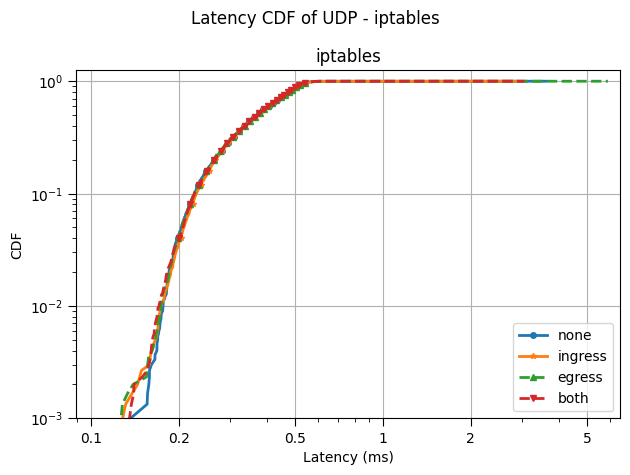


Mean Latencies ebpf, udp:
40816: mean=0.379ms, median=0.379ms, std=0.122ms, p95=0.543ms, p99=0.576ms
40817: mean=0.376ms, median=0.374ms, std=0.113ms, p95=0.541ms, p99=0.577ms
40818: mean=0.374ms, median=0.374ms, std=0.115ms, p95=0.538ms, p99=0.573ms
40819: mean=0.371ms, median=0.370ms, std=0.107ms, p95=0.535ms, p99=0.572ms


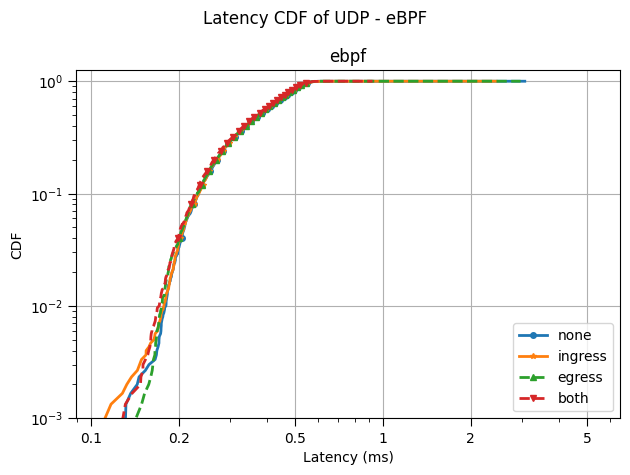

In [6]:
# UDP CDFs: separate figures per dataplane

# iptables
experimentstocompare = IPTABLES_UDP_EXPIDS
print(f"Mean Latencies {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
udp_xlim = get_shared_latency_xlim(IPTABLES_UDP_EXPIDS + EBPF_UDP_EXPIDS, delay_key="delay")
fig, ax = plt.subplots()
fig.suptitle('Latency CDF of UDP - iptables')
get_trace_dataset_and_plot(experimentstocompare, ax, index=None, delay_key="delay", xlim=udp_xlim)
plt.tight_layout()
plt.savefig('plots/latency_cdf_udp_iptables.pdf', format='pdf')
plt.show()

# eBPF
experimentstocompare = EBPF_UDP_EXPIDS
print(f"\nMean Latencies {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
fig, ax = plt.subplots()
fig.suptitle('Latency CDF of UDP - eBPF')
get_trace_dataset_and_plot(experimentstocompare, ax, index=None, delay_key="delay", xlim=udp_xlim)
plt.tight_layout()
plt.savefig('plots/latency_cdf_udp_ebpf.pdf', format='pdf')
plt.show()

# TCP

Mean Latencies iptables, tcp:
40826: mean=0.283ms, median=0.275ms, std=0.099ms, p95=0.437ms, p99=0.461ms
40827: mean=0.287ms, median=0.280ms, std=0.116ms, p95=0.438ms, p99=0.461ms
40828: mean=0.286ms, median=0.280ms, std=0.102ms, p95=0.437ms, p99=0.461ms
40829: mean=0.283ms, median=0.277ms, std=0.118ms, p95=0.436ms, p99=0.464ms


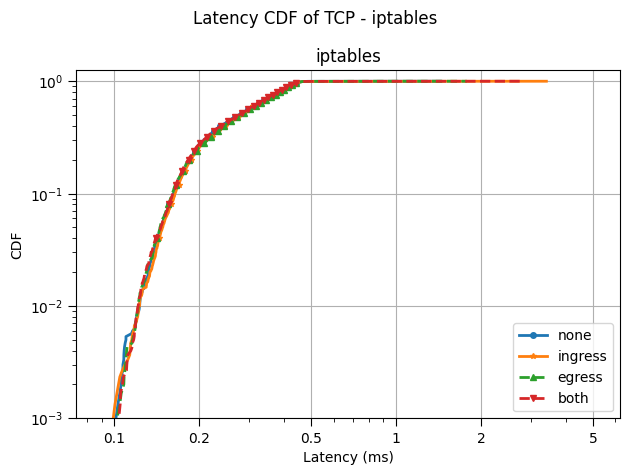


Mean Latencies ebpf, tcp:
40822: mean=0.277ms, median=0.270ms, std=0.111ms, p95=0.428ms, p99=0.452ms
40823: mean=0.275ms, median=0.272ms, std=0.107ms, p95=0.426ms, p99=0.450ms
40824: mean=0.278ms, median=0.269ms, std=0.159ms, p95=0.427ms, p99=0.453ms
40825: mean=0.276ms, median=0.270ms, std=0.100ms, p95=0.428ms, p99=0.453ms


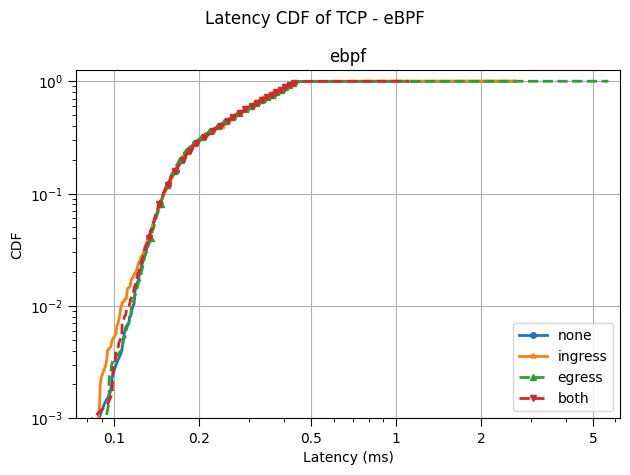

In [7]:
# TCP CDFs: separate figures per dataplane

# iptables
experimentstocompare = IPTABLES_TCP_EXPIDS
print(f"Mean Latencies {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
tcp_xlim = get_shared_latency_xlim(IPTABLES_TCP_EXPIDS + EBPF_TCP_EXPIDS)
fig, ax = plt.subplots()
fig.suptitle('Latency CDF of TCP - iptables')
get_trace_dataset_and_plot(experimentstocompare, ax, index=None, xlim=tcp_xlim)
plt.tight_layout()
plt.savefig('plots/latency_cdf_tcp_iptables.pdf', format='pdf')
plt.show()

# eBPF
experimentstocompare = EBPF_TCP_EXPIDS
print(f"\nMean Latencies {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
fig, ax = plt.subplots()
fig.suptitle('Latency CDF of TCP - eBPF')
get_trace_dataset_and_plot(experimentstocompare, ax, index=None, xlim=tcp_xlim)
plt.tight_layout()
plt.savefig('plots/latency_cdf_tcp_ebpf.pdf', format='pdf')
plt.show()

# HTTP

Mean Latencies iptables, http:
40780: mean=0.416ms, median=0.427ms, std=0.130ms, p95=0.582ms, p99=0.625ms
40781: mean=0.417ms, median=0.429ms, std=0.125ms, p95=0.581ms, p99=0.638ms
40782: mean=0.414ms, median=0.426ms, std=0.117ms, p95=0.577ms, p99=0.641ms
40783: mean=0.416ms, median=0.429ms, std=0.120ms, p95=0.576ms, p99=0.624ms


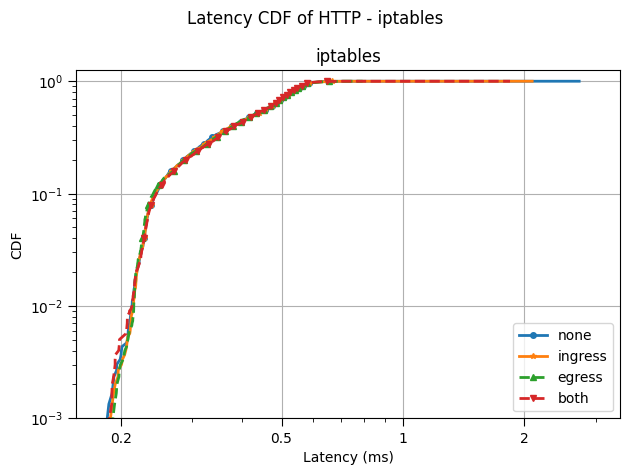

Mean Latencies ebpf, http:
40800: mean=0.409ms, median=0.420ms, std=0.133ms, p95=0.574ms, p99=0.619ms
40801: mean=0.411ms, median=0.424ms, std=0.136ms, p95=0.574ms, p99=0.621ms
40802: mean=0.408ms, median=0.421ms, std=0.138ms, p95=0.570ms, p99=0.616ms
40803: mean=0.410ms, median=0.421ms, std=0.144ms, p95=0.572ms, p99=0.632ms


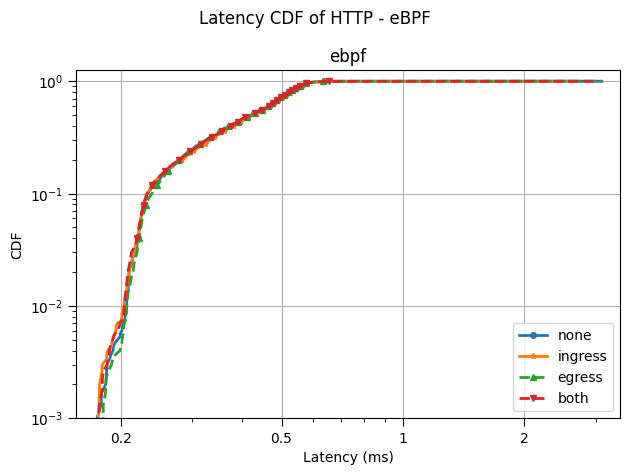

In [8]:
# HTTP CDFs: separate figures per dataplane

# iptables
experimentstocompare = IPTABLES_HTTP_EXPIDS
print(f"Mean Latencies {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
http_xlim = get_shared_latency_xlim(IPTABLES_HTTP_EXPIDS + EBPF_HTTP_EXPIDS)
fig, ax = plt.subplots()
fig.suptitle('Latency CDF of HTTP - iptables')
get_trace_dataset_and_plot(experimentstocompare, ax, index=None, xlim=http_xlim)
plt.tight_layout()
plt.savefig('plots/latency_cdf_http_iptables.pdf', format='pdf')
plt.show()

# eBPF
experimentstocompare = EBPF_HTTP_EXPIDS
print(f"Mean Latencies {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
fig, ax = plt.subplots()
fig.suptitle('Latency CDF of HTTP - eBPF')
get_trace_dataset_and_plot(experimentstocompare, ax, index=None, xlim=http_xlim)
plt.tight_layout()
plt.savefig('plots/latency_cdf_http_ebpf.pdf', format='pdf')
plt.show()

## Istio

Mean Latencies Istio - iptables, http:
40785: mean=0.971ms, median=0.983ms, std=0.157ms, p95=1.161ms, p99=1.224ms
40784: mean=0.979ms, median=0.995ms, std=0.133ms, p95=1.167ms, p99=1.242ms
40786: mean=1.002ms, median=1.016ms, std=0.151ms, p95=1.193ms, p99=1.257ms
40787: mean=0.981ms, median=0.996ms, std=0.167ms, p95=1.166ms, p99=1.253ms


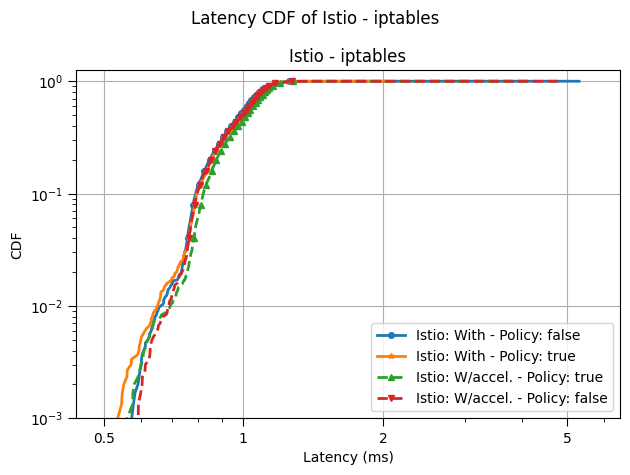

Mean Latencies Istio - ebpf, http:
40771: mean=0.987ms, median=0.996ms, std=0.206ms, p95=1.173ms, p99=1.244ms
40773: mean=0.970ms, median=0.985ms, std=0.156ms, p95=1.167ms, p99=1.235ms
40774: mean=0.999ms, median=1.004ms, std=0.210ms, p95=1.191ms, p99=1.270ms
40775: mean=0.981ms, median=0.992ms, std=0.186ms, p95=1.176ms, p99=1.243ms


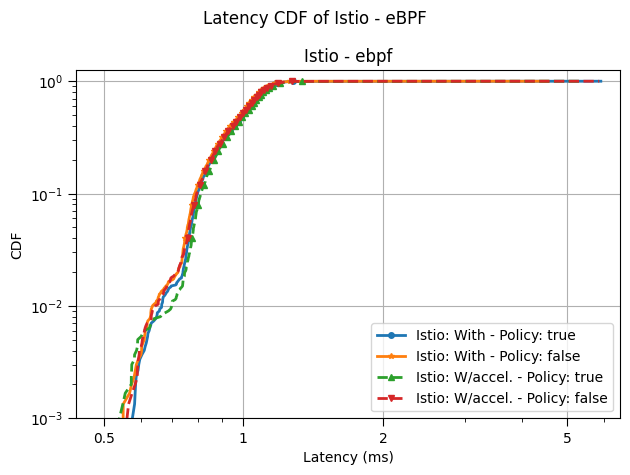

In [9]:
# Istio CDFs: separate figures per dataplane

# iptables Istio
experimentstocompare = IPTABLES_ISTIO_EXPIDS + IPTABLES_ISTIO_MERBRIDGE_EXPIDS
print(f"Mean Latencies Istio - {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
istio_xlim = get_shared_latency_xlim(IPTABLES_ISTIO_EXPIDS + IPTABLES_ISTIO_MERBRIDGE_EXPIDS + EBPF_ISTIO_EXPIDS + EBPF_ISTIO_MERBRIDGE_EXPIDS)
fig, ax = plt.subplots()
fig.suptitle('Latency CDF of Istio - iptables')
get_trace_dataset_and_plot_istio(experimentstocompare, ax, index=None, xlim=istio_xlim)
plt.tight_layout()
plt.savefig('plots/latency_cdf_istio_iptables.pdf', format='pdf', bbox_inches='tight')
plt.show()

# eBPF Istio
experimentstocompare = EBPF_ISTIO_EXPIDS + EBPF_ISTIO_MERBRIDGE_EXPIDS
print(f"Mean Latencies Istio - {get_experiment_info(experimentstocompare[0])['Dataplane']}, {get_experiment_info(experimentstocompare[0])['Protocol']}:")
fig, ax = plt.subplots()
fig.suptitle('Latency CDF of Istio - eBPF')
get_trace_dataset_and_plot_istio(experimentstocompare, ax, index=None, xlim=istio_xlim)
plt.tight_layout()
plt.savefig('plots/latency_cdf_istio_ebpf.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Significance testing

## eBPF vs iptables: 
$H_0$ : eBPF latency is not lower than iptables

$H_1$ : eBPF latency is lower than iptables.

In [10]:
from scipy.stats import ttest_ind


def pooled_latencies(experiment_ids, delay_key=None):
    return pd.concat(
        [get_combined_latency_series(expid, delay_key=delay_key) for expid in experiment_ids],
        ignore_index=True,
    )


def welch_one_sided_ttest(base_sample, compare_sample):
    test_result = ttest_ind(base_sample, compare_sample, equal_var=False)
    one_sided_p = test_result.pvalue / 2 if test_result.statistic > 0 else 1 - (test_result.pvalue / 2)
    return test_result.statistic, one_sided_p


ebpf_udp = EBPF_UDP_EXPIDS
ebpf_http = EBPF_HTTP_EXPIDS
iptables_udp = IPTABLES_UDP_EXPIDS
iptables_http = IPTABLES_HTTP_EXPIDS

ebpf_tcp = EBPF_TCP_EXPIDS
iptables_tcp = IPTABLES_TCP_EXPIDS

iptables_all = pooled_latencies(iptables_udp + iptables_http + iptables_tcp)
ebpf_all = pooled_latencies(ebpf_udp + ebpf_http + ebpf_tcp)
iptables_udp_latencies = pooled_latencies(iptables_udp, delay_key='delay')
ebpf_udp_latencies = pooled_latencies(ebpf_udp, delay_key='delay')
iptables_http_latencies = pooled_latencies(iptables_http)
ebpf_http_latencies = pooled_latencies(ebpf_http)
iptables_tcp_latencies = pooled_latencies(iptables_tcp)
ebpf_tcp_latencies = pooled_latencies(ebpf_tcp)

print(latency_summary)
print()
print('Welch one-sided t-test (H1: eBPF latency is lower than iptables latency)')

for label, iptables_sample, ebpf_sample in [
    ('Overall', iptables_all, ebpf_all),
    ('UDP', iptables_udp_latencies, ebpf_udp_latencies),
    ('HTTP', iptables_http_latencies, ebpf_http_latencies),
    ('TCP', iptables_tcp_latencies, ebpf_tcp_latencies),
]:
    statistic, p_value = welch_one_sided_ttest(iptables_sample, ebpf_sample)
    iptables_mean = iptables_sample.mean()
    ebpf_mean = ebpf_sample.mean()
    conclusion = 'reject H0' if p_value < 0.05 else 'fail to reject H0'
    print(
        f"{label}: t={statistic:.4f}, one-sided p={p_value:.6g}, "
        f"iptables mean={iptables_mean:.3f}ms, ebpf mean={ebpf_mean:.3f}ms -> {conclusion}"
    )


   Experiment Dataplane Protocol Policy Direction Istio Installed  \
0       40771      ebpf     http             none            with   
1       40773      ebpf     http             none            with   
2       40774      ebpf     http             none        W/accel.   
3       40775      ebpf     http             none        W/accel.   
4       40800      ebpf     http             none              no   
5       40801      ebpf     http          ingress              no   
6       40802      ebpf     http           egress              no   
7       40803      ebpf     http             both              no   
8       40780  iptables     http             none              no   
9       40781  iptables     http          ingress              no   
10      40782  iptables     http           egress              no   
11      40783  iptables     http             both              no   
12      40784  iptables     http             none            with   
13      40785  iptables     http  

# Network policy significance testing

## No Istio only

We test whether enabling a network policy increases latency compared with the no-policy baseline.

$H_0$ : network policies do not increase latency.

$H_1$ : network policies increase latency.

In [11]:
no_istio_experiments = {
    ('iptables', 'udp'): {
        'none': '40812',
        'ingress': '40813',
        'egress': '40814',
        'both': '40815',
    },
    ('ebpf', 'udp'): {
        'none': '40816',
        'ingress': '40817',
        'egress': '40818',
        'both': '40819',
    },
    ('iptables', 'http'): {
        'none': '40808',
        'ingress': '40809',
        'egress': '40810',
        'both': '40811',
    },
    ('ebpf', 'http'): {
        'none': '40800',
        'ingress': '40801',
        'egress': '40802',
        'both': '40803',
    },

    ('iptables', 'tcp'): {
        'none': '40826',
        'ingress': '40827',
        'egress': '40828',
        'both': '40829',
    },
    ('ebpf', 'tcp'): {
        'none': '40822',
        'ingress': '40823',
        'egress': '40824',
        'both': '40825',
    },
}

rows = []
for (dataplane, protocol), experiments in no_istio_experiments.items():
    baseline_exp = experiments['none']
    baseline_delay_key = 'delay' if protocol == 'udp' else 'Delay (s)'
    baseline_latencies = pooled_latencies([baseline_exp], delay_key=baseline_delay_key)

    for policy in ['ingress', 'egress', 'both']:
        policy_exp = experiments[policy]
        policy_latencies = pooled_latencies([policy_exp], delay_key=baseline_delay_key)
        statistic, p_value = welch_one_sided_ttest(policy_latencies, baseline_latencies)
        conclusion = 'reject H0' if p_value < 0.05 else 'fail to reject H0'
        rows.append({
            'Dataplane': dataplane,
            'Protocol': protocol,
            'Policy Direction': policy,
            'Baseline Experiment': baseline_exp,
            'Policy Experiment': policy_exp,
            'Baseline Mean': baseline_latencies.mean(),
            'Policy Mean': policy_latencies.mean(),
            't-statistic': statistic,
            'one-sided p-value': p_value,
            'Conclusion': conclusion,
        })

policy_test_summary = pd.DataFrame(rows).sort_values(['Protocol', 'Dataplane', 'Policy Direction']).reset_index(drop=True)
print('Welch one-sided t-test (H1: network policy increases latency; no Istio only)')
print(policy_test_summary.to_string(index=False))


Welch one-sided t-test (H1: network policy increases latency; no Istio only)
Dataplane Protocol Policy Direction Baseline Experiment Policy Experiment  Baseline Mean  Policy Mean  t-statistic  one-sided p-value        Conclusion
     ebpf     http             both               40800             40803       0.408914     0.410014     0.306080           0.379777 fail to reject H0
     ebpf     http           egress               40800             40802       0.408914     0.408251    -0.189247           0.575047 fail to reject H0
     ebpf     http          ingress               40800             40801       0.408914     0.411433     0.723519           0.234695 fail to reject H0
 iptables     http             both               40808             40811       0.415996     0.415934    -0.018180           0.507252 fail to reject H0
 iptables     http           egress               40808             40810       0.415996     0.417553     0.471361           0.318700 fail to reject H0
 iptables  